# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data.

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [ ]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [ ]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 500)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.2 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

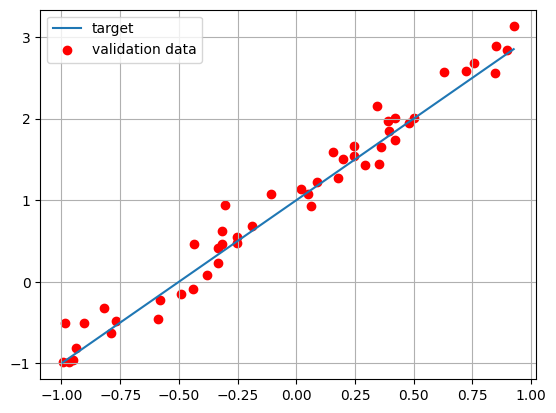

In [ ]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [ ]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [ ]:
# get a summary of our composed model
model.summary()

Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [ ]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train,
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.7898 - mse: 0.7898 - val_loss: 0.6806 - val_mse: 0.6806
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4421 - mse: 0.4421 - val_loss: 0.4066 - val_mse: 0.4066
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2564 - mse: 0.2564 - val_loss: 0.2554 - val_mse: 0.2554
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1580 - mse: 0.1580 - val_loss: 0.1719 - val_mse: 0.1719
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1062 - mse: 0.1062 - val_loss: 0.1234 - val_mse: 0.1234
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0779 - mse: 0.0779 - val_loss: 0.0948 - val_mse: 0.0948
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0623 - mse: 0.0623 - val_loss: 0.0775 - val_mse: 0.0775
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0536 - mse: 0.0536 - val_loss: 0.0665 - val_mse: 0.0665
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0486 - ms

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [ ]:
# return weights and biases
model.get_weights()

[array([[2.0099776]], dtype=float32), array([0.9776262], dtype=float32)]

In [ ]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0446 - mse: 0.0446

Test loss: 0.04464125633239746
Test accuracy: 0.04464125633239746


In [ ]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.5572e-04 - mse: 5.5572e-04

Test loss: 0.0005557152908295393
Test accuracy: 0.0005557152908295393


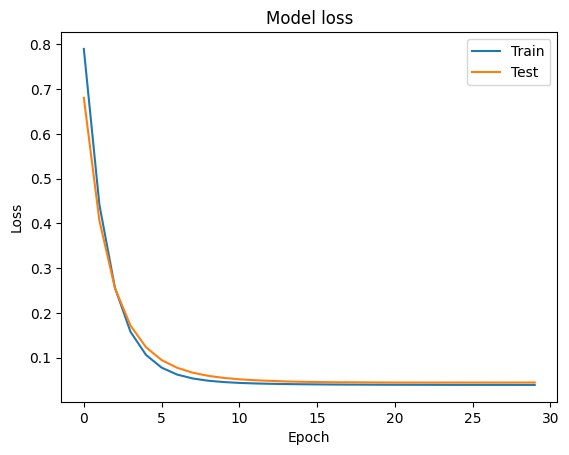

In [ ]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


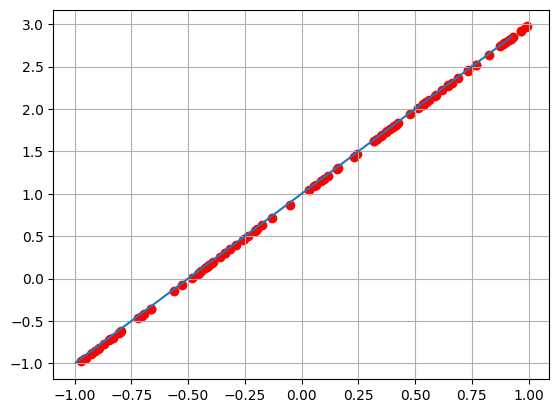

In [ ]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

In [ ]:
def create_model():
  model = tf.keras.Sequential()
  model.add(Input(shape=(1,)))
  model.add(Dense(1))

  # compile the model choosing optimizer, loss and metrics objects
  model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

  return model

Vedo la dipendenza rispetto al numero di epoche


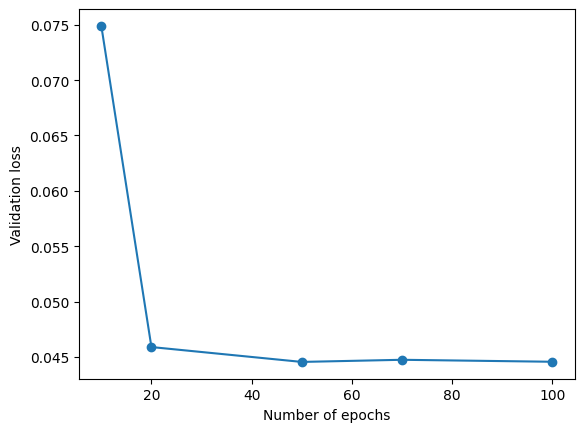

In [ ]:
epochs_values = [10, 20, 50, 70, 100]

results = []

for Nepochs in epochs_values:
    model = create_model()
    history = model.fit(x_train, y_train, epochs=Nepochs, batch_size=32, verbose=0)

    score = model.evaluate(x_valid, y_valid, verbose=0)

    results.append(score[0])

plt.plot(epochs_values, results, 'o-')
plt.xlabel('Number of epochs')
plt.ylabel('Validation loss')
plt.show()

Vedo la dipendenza rispetto al numero di dati di training


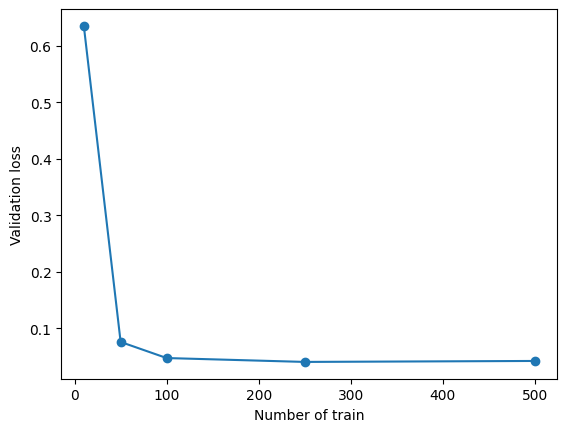

In [ ]:
train_values = [10, 50, 100, 250, 500]

results = []

for Ntrain in train_values:
  x_train = np.random.uniform(-1, 1, Ntrain)
  y_train = np.random.normal(m * x_train + b, sigma)
  model = create_model()

  history = model.fit(x_train, y_train, epochs=100, verbose=0)
  score = model.evaluate(x_valid, y_valid, verbose=0)

  results.append(score[0])

plt.plot(train_values, results, 'o-')
plt.xlabel('Number of train')
plt.ylabel('Validation loss')
plt.show()

Vedo la dipendenza rispetto al valore di sigma


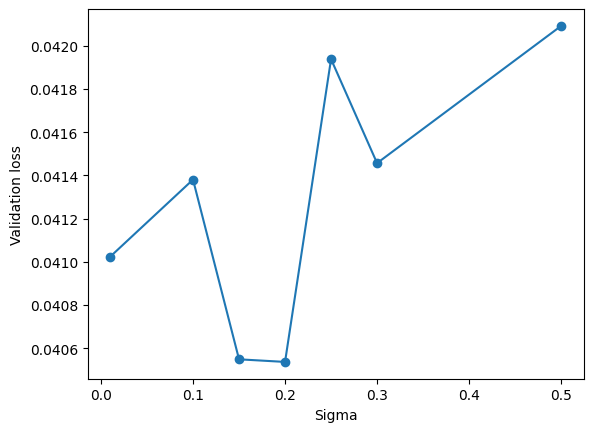

In [ ]:
train_values = [0.01, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5]

results = []

for Ntrain in train_values:
  x_train = np.random.uniform(-1, 1, 500)
  y_train = np.random.normal(m * x_train + b, sigma)
  model = create_model()

  history = model.fit(x_train, y_train, epochs=100, verbose=0)
  score = model.evaluate(x_valid, y_valid, verbose=0)

  results.append(score[0])

plt.plot(train_values, results, 'o-')
plt.xlabel('Sigma')
plt.ylabel('Validation loss')
plt.show()

In [ ]:
x_train = np.random.uniform(-1, 1, 100)
y_train = np.random.normal(m * x_train + b, 0.2)
model = create_model()
history = model.fit(x_train, y_train, epochs=100, verbose=0)
score = model.evaluate(x_valid, y_valid, verbose=0)
print('Loss = ', score[0])

Loss =  0.050963144749403


Si osserva che aumentando $N_{\text{epochs}}$ la validation loss diminuisce rapidamente nelle prime epoche, per poi stabilizzarsi. L'aumento di $N_{\text{train}}$ produce invece un miglioramento più significativo, infatti una maggiore quantità di dati consente al modello di stimare meglio i parametri della regressione lineare, anche qui c'è una stabilizzazione per $N_{\text{train} } > 100$. La variazione di $\sigma$ ha un effetto più contenuto nel range analizzato, in generale però un rumore maggiore rende più difficile la ricostruzione della relazione lineare.

Quindi il miglioramento del modello si ottiene utilizzando un numero sufficientemente elevato di dati di training e un numero di epoche adeguato al raggiungimento della convergenza.

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set?
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

In [ ]:
def f(x):
  return 4 - 3*x - 2*x**2 + 3*x**3

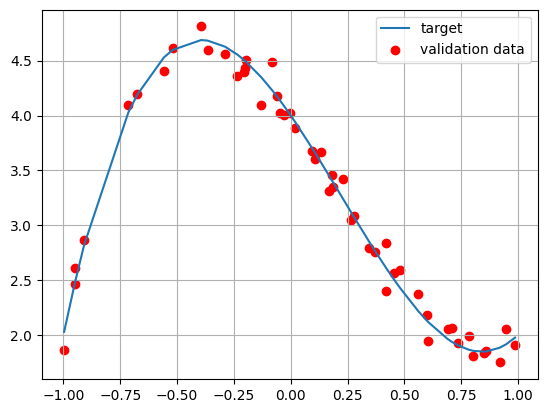

In [ ]:
N_train = 1000
N_valid = 50
sigma = 0.1

x_train = np.random.uniform(-1, 1, N_train)
y_train = np.random.normal(f(x_train), sigma, N_train)

x_valid = np.random.uniform(-1, 1, N_valid)
y_valid = np.random.normal(f(x_valid), sigma, N_valid)

y_target = f(x_valid)

ordine = np.argsort(x_valid)

import matplotlib.pyplot as plt
plt.plot(x_valid[ordine], y_target[ordine], label='target')
plt.scatter(x_valid[ordine], y_valid[ordine], color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model = Sequential()

model.add(Input(shape=(1,)))

model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

history = model.fit(x=x_train, y=y_train, batch_size=32, epochs=100, shuffle=True, validation_data=(x_valid, y_valid))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 10.4295 - mse: 10.4295 - val_loss: 8.8952 - val_mse: 8.8952
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4145 - mse: 7.4145 - val_loss: 5.4903 - val_mse: 5.4903
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6621 - mse: 3.6621 - val_loss: 2.2292 - val_mse: 2.2292
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4342 - mse: 1.4342 - val_loss: 1.2186 - val_mse: 1.2186
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0033 - mse: 1.0033 - val_loss: 0.9565 - val_mse: 0.9565
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8035 - mse: 0.8035 - val_loss: 0.7694 - val_mse: 0.7694
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6550 - mse: 0.6550 - val_loss: 0.6154 - val_mse: 0.6154
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5271 - mse: 0.5271 - val_loss: 0.4906 - val_mse: 0.4906
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

In [ ]:
score = model.evaluate(x_valid, y_valid, verbose=1)

print()
print('Test loss:', score[0])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0138 - mse: 0.0138

Test loss: 0.01381540298461914


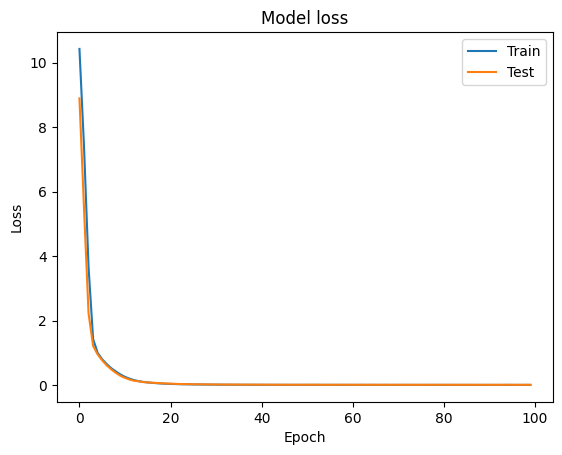

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


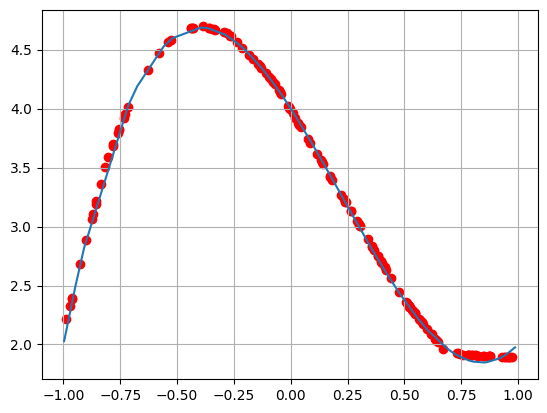

In [ ]:
x_predicted = np.random.uniform(-1, 1, 150)
y_predicted = model.predict(x_predicted)

ordine_pred = np.argsort(x_predicted)
ordine_val = np.argsort(x_valid)

plt.scatter(x_predicted[ordine_pred], y_predicted[ordine_pred], color='r')
plt.plot(x_valid[ordine_val], y_target[ordine_val])
plt.grid(True)
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


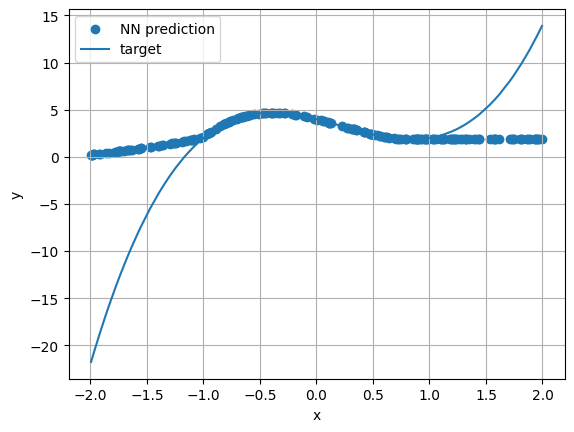

In [ ]:
x_test_out = np.random.uniform(-2, 2, 200)
y_test_out = f(x_test_out)

y_pred_out = model.predict(x_test_out)

ordine = np.argsort(x_test_out)

plt.scatter(x_test_out[ordine], y_pred_out[ordine], label='NN prediction')
plt.plot(x_test_out[ordine], y_test_out[ordine], label='target')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Per il fit è stata utilizzata una rete neurale costituita da due hidden layers con $32$ neuroni ciascuno e funzione di attivazione ReLU. Per il neurone di output è stata utilizzata un'attivazione lineare. Come ottimizzatore è stato scelto Adam, mentre la funzione di loss utilizzata è la mean squared error (MSE).

Con $N_{\mathrm{train}}=1000$ e $\sigma=0.1$, la rete riesce a riprodurre molto bene la funzione target nell'intervallo $[-1,1]$, ottenendo una test loss di circa $0.0138$. Questo mostra che il modello ha una buona capacità di interpolazione sui dati appartenenti alla regione utilizzata durante il training.

Tuttavia, considerando punti al di fuori dell'intervallo di training, la qualità della predizione è diminuita significativamente, come mostrato nell'ultimo grafico.

Questo evidenzia il ruolo della complessità del modello: aumentando il numero di neuroni e di layer aumenta la capacità della rete di adattarsi ai dati, ma ciò non garantisce necessariamente una buona capacità di generalizzazione al di fuori della regione in cui il modello è stato addestrato.

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

In [ ]:
def f(x, y):
  return np.sin(x**2 + y**2)

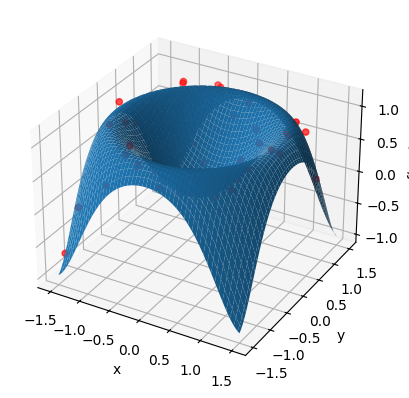

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_train = 1000
N_valid = 50
sigma = 0.1

x_train = np.random.uniform(-1.5, 1.5, N_train)
y_train = np.random.uniform(-1.5, 1.5, N_train)
z_train = np.random.normal(f(x_train, y_train), sigma)

x_valid = np.random.uniform(-1.5, 1.5, N_valid)
y_valid = np.random.uniform(-1.5, 1.5, N_valid)
z_valid = np.random.normal(f(x_valid, y_valid), sigma)

x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
Z_true = f(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z_true)
ax.scatter(x_valid, y_valid, z_valid, color='red')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')

plt.show()

In [ ]:
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile( optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit( np.column_stack((x_train, y_train)), z_train, epochs=100, batch_size=32, validation_split=0.2, shuffle=True)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4413 - mae: 0.5687 - val_loss: 0.2389 - val_mae: 0.3635
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1703 - mae: 0.2913 - val_loss: 0.2012 - val_mae: 0.3160
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1493 - mae: 0.2864 - val_loss: 0.1891 - val_mae: 0.3172
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1427 - mae: 0.2738 - val_loss: 0.1813 - val_mae: 0.3064
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1356 - mae: 0.2710 - val_loss: 0.1766 - val_mae: 0.2965
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1296 - mae: 0.2641 - val_loss: 0.1681 - val_mae: 0.2953
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1245 - mae: 0.2597 - val_loss: 0.1630 - val_mae: 0.2831
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1184 - mae: 0.2496 - val_loss: 0.1515 - val_mae: 0.2751
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.11

In [ ]:
X_valid = np.column_stack((x_valid, y_valid))

score = model.evaluate(X_valid, z_valid, verbose=0)

print('Nel range di training: ')
print('Test MSE:', score[0])
print('Test MAE:', score[1])


Test loss: 0.015392613597214222
Test accuracy: 0.09334004670381546


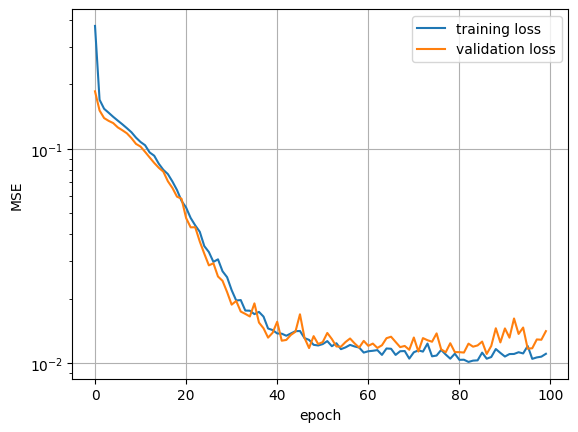

In [ ]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


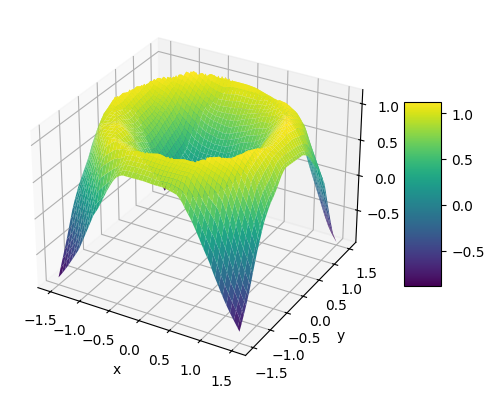

In [ ]:
x_predicted = np.linspace(-1.5, 1.5, 100)
y_predicted = np.linspace(-1.5, 1.5, 100)

X_predicted, Y_predicted = np.meshgrid(x_predicted, y_predicted)

XY_predicted = np.column_stack((X_predicted.ravel(), Y_predicted.ravel()))
Z_predicted = model.predict(XY_predicted)
Z_predicted = Z_predicted.reshape(X_predicted.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_predicted, Y_predicted, Z_predicted, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

In [ ]:
N_test = 1000

x_test = np.random.uniform(-3, 3, N_test)
y_test = np.random.uniform(-3, 3, N_test)

z_test = f(x_test, y_test)

X_test = np.column_stack((x_test, y_test))

score = model.evaluate(X_test, z_test, verbose=0)

print("Test MSE:", score[0])
print("Test MAE:", score[1])

TypeError: f() takes 1 positional argument but 2 were given